In [1]:
import os
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Cấu hình giao diện đồ thị để hiển thị đẹp mắt trong Jupyter
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [2]:
zip_path = r"D:\UNI\NCKH\CTD2026_DT049\Dataset\processed\cleaned_amazon_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    csv_files = [f for f in z.namelist() if f.endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("Không tìm thấy file .csv nào!")

    # Đọc file dữ liệu
    with z.open(csv_files[0]) as f:
        df = pd.read_csv(f)

print(f" Đã tải dữ liệu thành công! Số lượng dòng: {df.shape[0]}, Số lượng cột: {df.shape[1]}")

C:\Users\trong\AppData\Local\Temp\ipykernel_15224\641970301.py:10: DtypeWarning: Columns (0: about_item, 1: best_sellers_rank, 2: model_number, 3: product_description, 4: rating_distribution_1star, 5: rating_distribution_2star, 6: rating_distribution_3star, 7: rating_distribution_4star, 8: rating_distribution_5star, 9: recent_purchases, 10: scrape_time, 11: seller_page_url, 12: productasin, 13: productvariant, 14: reviewid, 15: reviewmetadata, 16: reviewtext, 17: reviewtitle, 18: reviewurl, 19: verifiedpurchase, 20: videos_0, 21: verified_purchases) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


 Đã tải dữ liệu thành công! Số lượng dòng: 227695, Số lượng cột: 45


In [3]:
print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head())

print("\n--- THÔNG TIN CÁC CỘT DỮ LIỆU ---")
display(df.info())

print("\n--- KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---")
missing_val = df.isnull().sum()
display(missing_val[missing_val > 0] if missing_val.sum() > 0 else "Tuyệt vời! Không có dữ liệu khuyết thiếu.")

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,about_item,asin,availability,best_sellers_rank,brand_name,list_price,manufacturer,model_number,price_value,product_description,...,sentiment_score,_source,parent_asin,target,verified_purchases,text,helpful_vote,user_id,timestamp,combined_text
0,Premium Comfort: Crafted from a high-quality c...,B0B59BJG6Y,in stock,"#56,836 in Clothing, Shoes & Jewelry (See Top ...",mlyenx store,NaN,unknown,NaN,39.9926,NaN,...,0.292024,ecommerce,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Premium Comfort: Crafted from a high-quality...
1,Material: Men's polo shirt is made of soft pol...,B0DLGB4RYH,in stock,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",coofandy store,NaN,unknown,NaN,19.9920,NaN,...,0.560000,ecommerce,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Material: Men's polo shirt is made of soft p...
2,"PERFORMANCE:These men polo shirts are soft,lig...",B0DRXF62JH,in stock,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",zity store,NaN,unknown,NaN,29.9950,NaN,...,0.192321,ecommerce,NaN,NaN,NaN,NaN,0.0,NaN,NaN,"PERFORMANCE:These men polo shirts are soft,l..."
3,【Material】: These golf shirts for men are made...,B0DK5FZ325,in stock,"#194,649 in Clothing, Shoes & Jewelry (See Top...",rouen store,NaN,unknown,NaN,32.9500,NaN,...,0.307949,ecommerce,NaN,NaN,NaN,NaN,0.0,NaN,NaN,【Material】: These golf shirts for men are ma...
4,MOISTURE WICKING: The fabric of the summer gol...,B0BGXTC1FR,in stock,"#3,664 in Clothing, Shoes & Jewelry (See Top 1...",v valanch store,NaN,unknown,NaN,26.9931,NaN,...,0.250000,ecommerce,NaN,NaN,NaN,NaN,0.0,NaN,NaN,MOISTURE WICKING: The fabric of the summer g...



--- THÔNG TIN CÁC CỘT DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 227695 entries, 0 to 227694
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   about_item                 728 non-null     str    
 1   asin                       221867 non-null  str    
 2   availability               227695 non-null  str    
 3   best_sellers_rank          558 non-null     str    
 4   brand_name                 227695 non-null  str    
 5   list_price                 0 non-null       float64
 6   manufacturer               227695 non-null  str    
 7   model_number               199 non-null     str    
 8   price_value                227695 non-null  float64
 9   product_description        271 non-null     str    
 10  rating_count               0 non-null       float64
 11  rating_distribution_1star  728 non-null     str    
 12  rating_distribution_2star  728 non-null     str    
 13  ratin

None


--- KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---


about_item                   226967
asin                           5828
best_sellers_rank            227137
list_price                   227695
model_number                 227496
product_description          227424
rating_count                 227695
rating_distribution_1star    226967
rating_distribution_2star    226967
rating_distribution_3star    226967
rating_distribution_4star    226967
rating_distribution_5star    226967
rating_stars                 227695
recent_purchases             227126
scrape_time                  226967
seller_page_url              227269
title                          5828
rank_1                       227155
productasin                  221368
productvariant               221859
rating                          236
reviewid                     221368
reviewmetadata               221399
reviewposition               221368
reviewtext                   221406
reviewtitle                  221382
reviewurl                    221368
verifiedpurchase            

In [4]:
# Danh sách các cột số quan trọng cần xem xét thống kê
numeric_cols_to_check = [
    "price_value",
    "list_price",
    "rating_stars",
    "rating",
    "rating_count",
    "sentiment_score",
    "helpful_vote",
    "recent_purchases",
]
available_num_cols = [col for col in numeric_cols_to_check if col in df.columns]

print("--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CHÍNH ---")
display(df[available_num_cols].describe().T)

--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CHÍNH ---


,count,mean,std,min,25%,50%,75%,max
price_value,227695.0,28.969791,1.513422,5.4573,28.95,28.95,28.95,249.99
list_price,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating_stars,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,227459.0,3.131294,1.397192,1.0000,2.00,3.00,4.00,5.00
rating_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_score,227695.0,0.300210,0.036361,-1.0000,0.30,0.30,0.30,1.00
helpful_vote,227695.0,0.925905,5.432671,0.0000,0.00,0.00,1.00,954.00


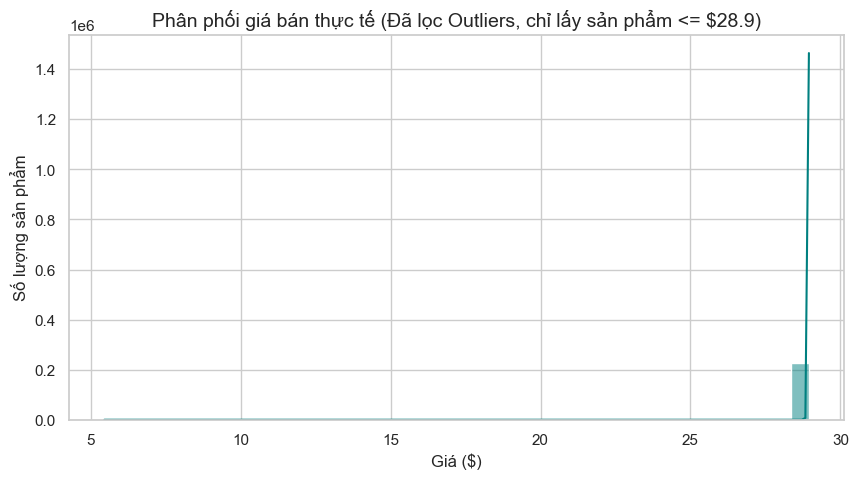

In [13]:
# CELL 5 (Cập nhật): Phân tích Giá bán thực tế
plt.figure(figsize=(10, 5))

# Tính toán giá trị ở phân vị 98% để giới hạn đồ thị không bị kéo giãn bởi outlier
if "price_value" in df.columns and df["price_value"].notna().sum() > 0:
    max_price_limit = df["price_value"].quantile(0.98)

    # Lọc dữ liệu dưới mức phân vị 98% để vẽ
    filtered_price = df[df["price_value"] <= max_price_limit]["price_value"]

    sns.histplot(filtered_price, kde=True, color="teal", bins=40)
    plt.title(
        f"Phân phối giá bán thực tế (Đã lọc Outliers, chỉ lấy sản phẩm <= ${max_price_limit:.1f})"
    )
    plt.xlabel("Giá ($)")
    plt.ylabel("Số lượng sản phẩm")
else:
    print("Cột price_value không hợp lệ hoặc không có dữ liệu.")

plt.show()

Cột rating_stars không thể chuyển sang dạng số.


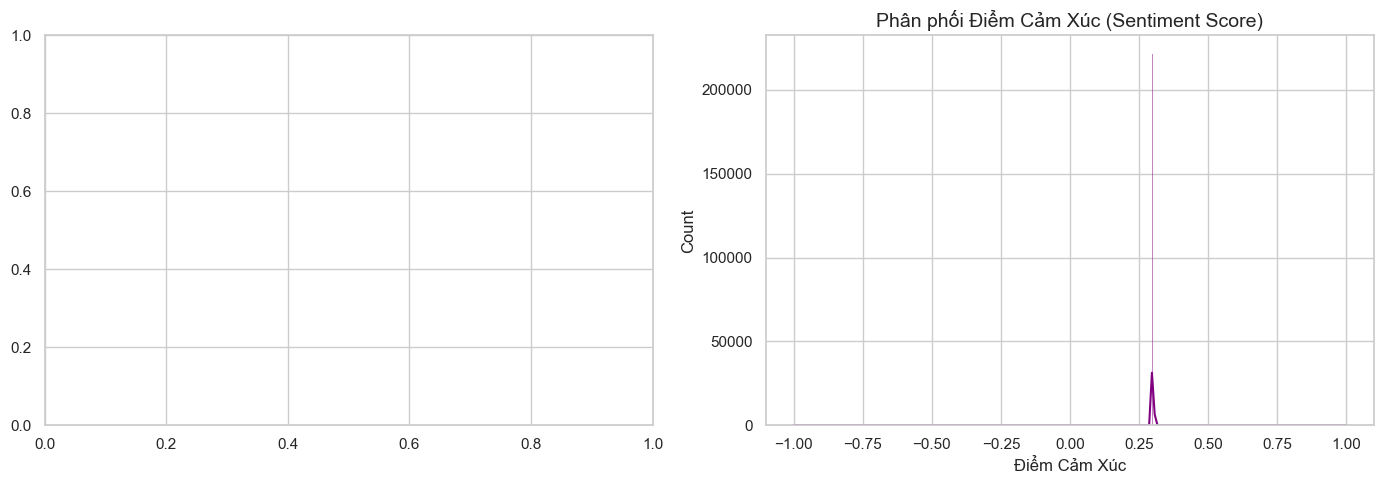

In [14]:
# CELL 6 (Cập nhật): Phân tích Điểm đánh giá và Cảm xúc
plt.figure(figsize=(14, 5))

# Sửa lỗi hiển thị Rating Stars
plt.subplot(1, 2, 1)
if "rating_stars" in df.columns:
    # Ép kiểu về số, nếu có chữ sẽ tự động chuyển thành NaN để không lỗi đồ thị
    rating_numeric = pd.to_numeric(df["rating_stars"], errors="coerce").dropna()

    if len(rating_numeric) > 0:
        sns.countplot(
            x=rating_numeric, hue=rating_numeric, palette="Blues_r", legend=False
        )
        plt.title("Phân phối Điểm đánh giá Sản phẩm (Rating Stars)")
        plt.xlabel("Số sao")
        plt.ylabel("Số lượng")
    else:
        print("Cột rating_stars không thể chuyển sang dạng số.")
else:
    print("Không tìm thấy cột rating_stars.")

# Biểu đồ cột cho sentiment_score
plt.subplot(1, 2, 2)
if "sentiment_score" in df.columns:
    sns.histplot(df["sentiment_score"].dropna(), kde=True, color="purple")
    plt.title("Phân phối Điểm Cảm Xúc (Sentiment Score)")
    plt.xlabel("Điểm Cảm Xúc")

plt.tight_layout()
plt.show()

C:\Users\trong\AppData\Local\Temp\ipykernel_15224\2746065658.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


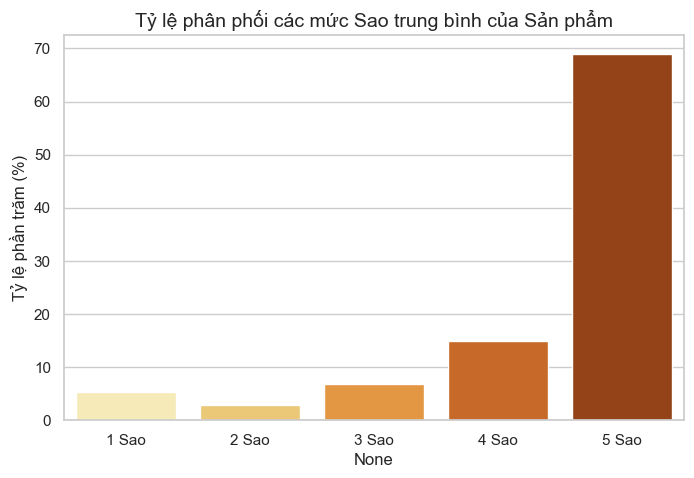

In [8]:
# Tính trung bình phần trăm phân phối các sao của toàn bộ tập dữ liệu
star_cols = [
    "rating_distribution_1star",
    "rating_distribution_2star",
    "rating_distribution_3star",
    "rating_distribution_4star",
    "rating_distribution_5star",
]
available_stars = [col for col in star_cols if col in df.columns]

if available_stars:
    mean_distribution = (
        df[available_stars]
        .replace(r"%", "", regex=True)
        .astype(float)
        .mean()
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=mean_distribution.index, y=mean_distribution.values, palette="YlOrBr"
    )
    plt.title("Tỷ lệ phân phối các mức Sao trung bình của Sản phẩm")
    plt.ylabel("Tỷ lệ phần trăm (%)")
    plt.xticks(
        ticks=range(5), labels=["1 Sao", "2 Sao", "3 Sao", "4 Sao", "5 Sao"]
    )
    plt.show()
else:
    print("Không tìm thấy các cột phân phối sao.")

C:\Users\trong\AppData\Local\Temp\ipykernel_15224\4202198364.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
C:\Users\trong\AppData\Local\Temp\ipykernel_15224\4202198364.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sellers.values, y=top_sellers.index, palette="magma")


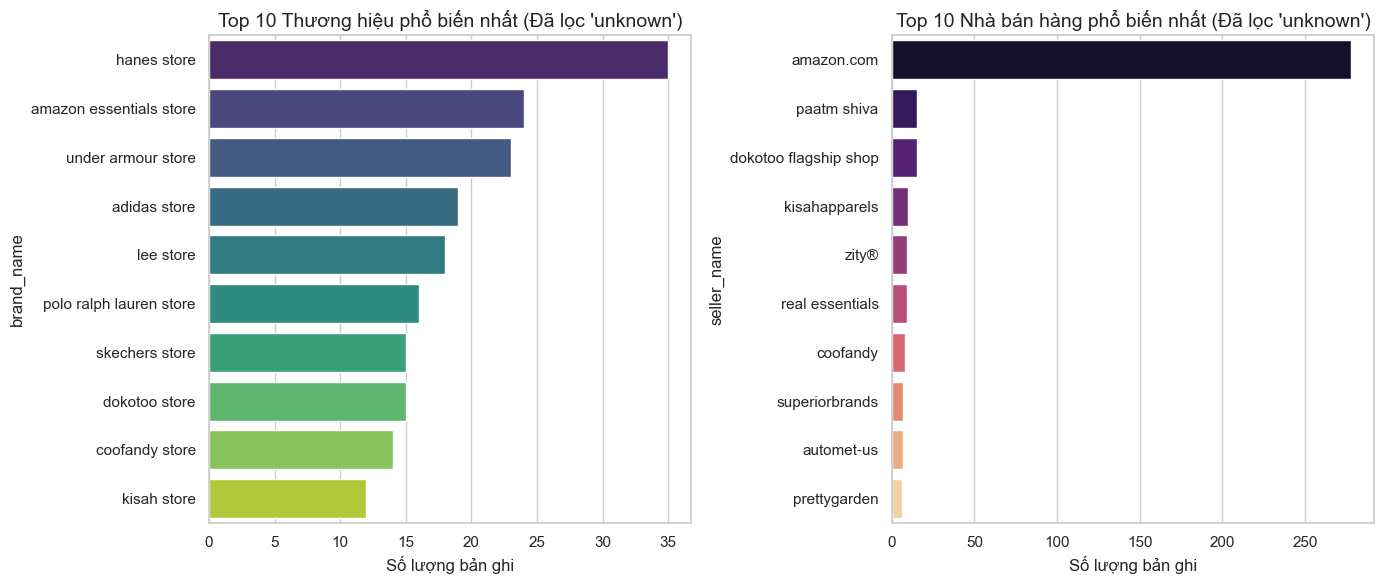

In [15]:
# CELL 8 (Cập nhật): Top Thương hiệu & Nhà bán hàng (Loại bỏ 'unknown')
plt.figure(figsize=(14, 6))

# Top 10 Thương hiệu (Bỏ qua 'unknown')
plt.subplot(1, 2, 1)
if "brand_name" in df.columns:
    # Lọc bỏ các giá trị dạng 'unknown', 'nan', hoặc trống
    filtered_brands = df[
        ~df["brand_name"].astype(str).str.lower().isin(["unknown", "nan", ""])
    ]
    top_brands = filtered_brands["brand_name"].value_counts().head(10)

    if not top_brands.empty:
        sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
        plt.title("Top 10 Thương hiệu phổ biến nhất (Đã lọc 'unknown')")
        plt.xlabel("Số lượng bản ghi")
    else:
        print("Không có thương hiệu nào khác ngoài 'unknown'")

# Top 10 Nhà bán hàng (Bỏ qua 'unknown')
plt.subplot(1, 2, 2)
if "seller_name" in df.columns:
    filtered_sellers = df[
        ~df["seller_name"].astype(str).str.lower().isin(["unknown", "nan", ""])
    ]
    top_sellers = filtered_sellers["seller_name"].value_counts().head(10)

    if not top_sellers.empty:
        sns.barplot(x=top_sellers.values, y=top_sellers.index, palette="magma")
        plt.title("Top 10 Nhà bán hàng phổ biến nhất (Đã lọc 'unknown')")
        plt.xlabel("Số lượng bản ghi")
    else:
        print("Không có nhà bán hàng nào khác ngoài 'unknown'")

plt.tight_layout()
plt.show()

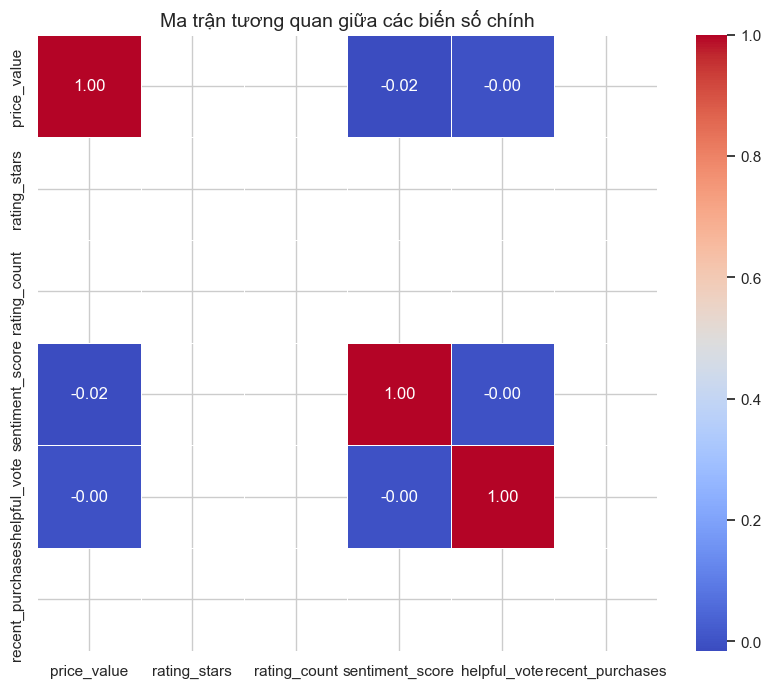

In [11]:
# Tìm mối tương quan giữa Giá, Lượt mua gần đây, Rating và Số lượng Helpful Vote
correlation_cols = [
    "price_value",
    "rating_stars",
    "rating_count",
    "sentiment_score",
    "helpful_vote",
    "recent_purchases",
]
available_corr_cols = [col for col in correlation_cols if col in df.columns]

if len(available_corr_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr_df = df[available_corr_cols].copy()
    for col in corr_df.columns:
        if corr_df[col].dtype == "object":
            corr_df[col] = corr_df[col].astype(str).str.replace(r"[^\d\.\-]", "", regex=True)
        corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")
    corr_matrix = corr_df.corr()
    sns.heatmap(
        corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
    )
    plt.title("Ma trận tương quan giữa các biến số chính")
    plt.show()

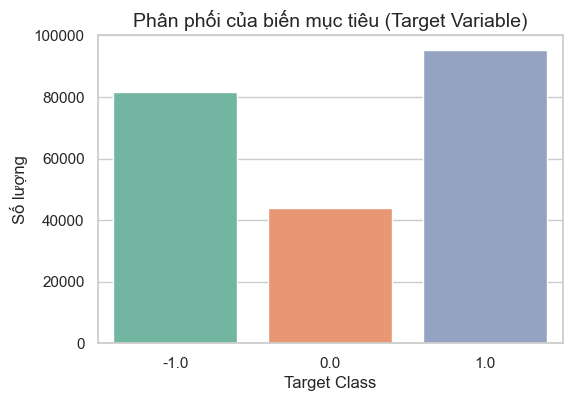

Tỷ lệ các lớp trong biến Target:
target
 1.0    43.108181
-1.0    36.961368
 0.0    19.930451
Name: proportion, dtype: float64


In [12]:
if "target" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        x="target", data=df, hue="target", palette="Set2", legend=False
    )
    plt.title("Phân phối của biến mục tiêu (Target Variable)")
    plt.xlabel("Target Class")
    plt.ylabel("Số lượng")
    plt.show()

    # In tỷ lệ phần trăm các lớp để kiểm tra mất cân bằng dữ liệu (Imbalance)
    print("Tỷ lệ các lớp trong biến Target:")
    print(df["target"].value_counts(normalize=True) * 100)
else:
    print("Không có cột 'target' hoặc cột này đóng vai trò khác.")

C:\Users\trong\AppData\Local\Temp\ipykernel_15224\3040978219.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


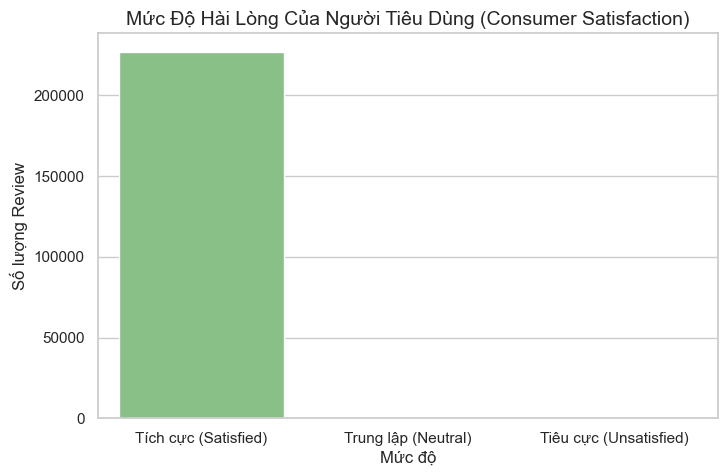

satisfaction_level
Tích cực (Satisfied)      99.764158
Tiêu cực (Unsatisfied)     0.125607
Trung lập (Neutral)        0.110235
Name: proportion, dtype: float64


In [18]:
# CELL 11: Phân tích Mức độ hài lòng của người tiêu dùng
import numpy as np


def categorize_sentiment(score):
    if score > 0:
        return "Tích cực (Satisfied)"
    elif score < 0:
        return "Tiêu cực (Unsatisfied)"
    else:
        return "Trung lập (Neutral)"


if "sentiment_score" in df.columns:
    # Gán nhãn mức độ hài lòng
    df["satisfaction_level"] = df["sentiment_score"].apply(categorize_sentiment)

    # Vẽ biểu đồ
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x="satisfaction_level",
        data=df,
        order=["Tích cực (Satisfied)", "Trung lập (Neutral)", "Tiêu cực (Unsatisfied)"],
        palette="Accent",
    )
    plt.title("Mức Độ Hài Lòng Của Người Tiêu Dùng (Consumer Satisfaction)")
    plt.xlabel("Mức độ")
    plt.ylabel("Số lượng Review")
    plt.show()

    print(df["satisfaction_level"].value_counts(normalize=True) * 100)

C:\Users\trong\AppData\Local\Temp\ipykernel_15224\4234995843.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(quality_counts.values())[:7], y=list(quality_counts.keys())[:7], ax=axes[0], palette="Blues_r")
C:\Users\trong\AppData\Local\Temp\ipykernel_15224\4234995843.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(service_counts.values())[:7], y=list(service_counts.keys())[:7], ax=axes[1], palette="Greens_r")
C:\Users\trong\AppData\Local\Temp\ipykernel_15224\4234995843.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

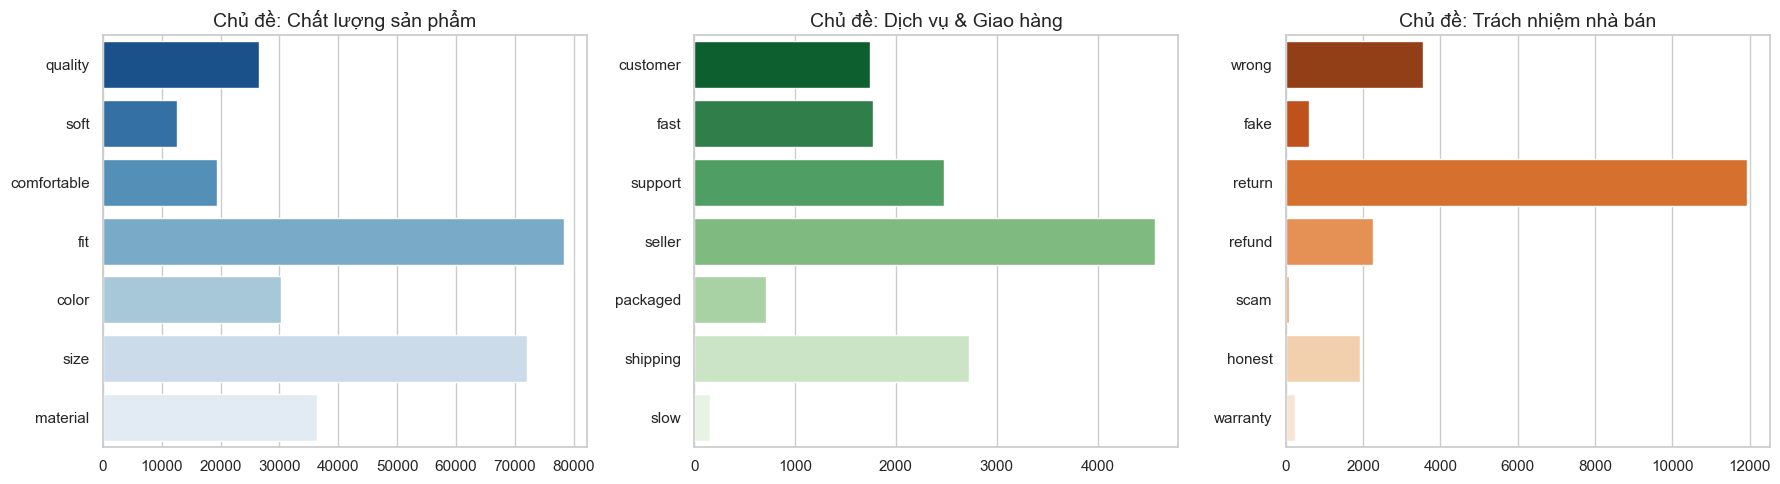

In [17]:
# CELL 12: Phân tích tần suất từ khóa theo Chủ đề phản hồi (ESG Proxy)
from collections import Counter
import re

# Định nghĩa bộ từ khóa gợi ý (Bạn có thể dịch sang tiếng Anh nếu data là tiếng Anh)
keywords_quality = ["fabric", "size", "material", "torn", "color", "fit", "quality", "soft", "comfortable"]
keywords_service = ["delivery", "shipping", "packaged", "support", "fast", "slow", "seller", "customer"]
keywords_responsibility = ["return", "refund", "fake", "scam", "honest", "warranty", "wrong"]

def count_keywords(text_series, keyword_list):
    words = " ".join(text_series.astype(str).dropna()).lower()
    tokens = re.findall(r'\b\w+\b', words)
    matched_words = [w for w in tokens if w in keyword_list]
    return Counter(matched_words)

if 'cleaned_review_text' in df.columns:
    # Trích xuất tần suất
    quality_counts = count_keywords(df['cleaned_review_text'], keywords_quality)
    service_counts = count_keywords(df['cleaned_review_text'], keywords_service)
    resp_counts = count_keywords(df['cleaned_review_text'], keywords_responsibility)
    
    # Trực quan hóa Top từ khóa xuất hiện trong phản hồi
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Đồ thị Chất lượng
    if quality_counts:
        sns.barplot(x=list(quality_counts.values())[:7], y=list(quality_counts.keys())[:7], ax=axes[0], palette="Blues_r")
        axes[0].set_title("Chủ đề: Chất lượng sản phẩm")
    
    # Đồ thị Dịch vụ
    if service_counts:
        sns.barplot(x=list(service_counts.values())[:7], y=list(service_counts.keys())[:7], ax=axes[1], palette="Greens_r")
        axes[1].set_title("Chủ đề: Dịch vụ & Giao hàng")
        
    # Đồ thị Trách nhiệm
    if resp_counts:
        sns.barplot(x=list(resp_counts.values())[:7], y=list(resp_counts.keys())[:7], ax=axes[2], palette="Oranges_r")
        axes[2].set_title("Chủ đề: Trách nhiệm nhà bán")
        
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy cột cleaned_review_text để phân tích chủ đề.")